# Module 5 — Feedforward Autoencoder on SWaT

## Context

**Modules 3–4 established the baselines:** Mahalanobis distance (F1 0.7240) outperforms both univariate z-score (F1 0.4249) and Isolation Forest (F1 0.5154) on SWaT. The key insight: SWaT attacks violate *sensor correlations*, and Mahalanobis encodes those correlations explicitly via the full covariance matrix.

**Module 5 asks:** Can a neural autoencoder — trained exclusively on normal operation data — learn those sensor correlations in its weights and beat Mahalanobis?

## What is a reconstruction-based autoencoder?

An autoencoder is a neural network trained to **compress-then-reconstruct** its input:

```
Input x (25 features)
    ↓ Encoder: 25 → 32 → 16 → 8
Latent z (8 dimensions)
    ↓ Decoder: 8 → 16 → 32 → 25
Reconstruction x̂ (25 features)
```

The model is trained to minimise `MSE(x, x̂)` — reconstruction error. Because the bottleneck (8 dimensions) forces the encoder to compress, the model can only learn the **dominant patterns** that appear repeatedly in training.

**Why this works for anomaly detection:** Train only on normal data. The model memorises the *vocabulary of normal* — the typical sensor correlations, operating modes, and value distributions seen during 7 days of normal plant operation. At test time:

- **Normal rows:** the input looks like something the model trained on → low reconstruction error  
- **Attack rows:** sensor correlations are violated (e.g., pressure doesn't follow the expected relationship with flow) → the decoder can't faithfully reconstruct the anomalous pattern → **high reconstruction error**

Crucially, this works even when *individual* sensor values are within the normal range. The model has learned **joint** sensor behaviour — it detects when the combination is impossible, not just when a single sensor is extreme. This is the same intuition as Mahalanobis distance, but encoded in neural network weights rather than a covariance matrix.

## Why SWaT is a good test case

SWaT's 36 attack scenarios are designed to be stealthy: they violate sensor correlations while keeping individual readings plausible. Fixed thresholds and univariate z-score miss them entirely because each sensor, in isolation, looks normal. Mahalanobis catches them by consulting its covariance matrix. An autoencoder should achieve similar discrimination — but through learned representations that may capture nonlinear correlations that the linear covariance matrix misses.

## Feature note: 25 sensors (AIT201 dropped)

The source CSV has empty fields for AIT201 across 71.5% of training rows (one contiguous block). `pandas` silently skips NaN rows in `mean()`/`cov()`, so Module 3 was unaffected. PyTorch tensors propagate NaN through the loss, so we drop AIT201 rather than forward-filling a stale constant. The comparison to Mahalanobis remains fair — both use the same underlying sensor set.

## Key comparison target

| Method | F1 | Precision | Recall |
|--------|----|-----------|--------|
| Univariate Z-Score (Module 3) | 0.4249 | 0.2967 | 0.7480 |
| Isolation Forest (Module 4) | 0.5154 | 0.4145 | 0.6812 |
| Mahalanobis Distance (Module 3) | **0.7240** | **0.7277** | **0.7202** |
| **Autoencoder (this module)** | ? | ? | ? |

Target: beat IF (0.5154). Stretch goal: approach Mahalanobis (0.7240).

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

# --- Constants ---
FEATURES = [
    'FIT101', 'LIT101',
    # AIT201 omitted: empty fields in the source CSV produce 991,800 NaN values
    # (71.5% of training rows, one contiguous end-block). pandas mean/cov silently
    # skip NaN rows, so Module 3 was unaffected. PyTorch tensors propagate NaN
    # through the loss — so we drop the sensor entirely rather than ffill a stale
    # constant across 71.5% of the training set.
    'AIT202', 'AIT203', 'FIT201',
    'DPIT301', 'FIT301', 'LIT301',
    'AIT401', 'AIT402', 'FIT401', 'LIT401',
    'AIT501', 'AIT502', 'AIT503', 'AIT504',
    'FIT501', 'FIT502', 'FIT503', 'FIT504',
    'PIT501', 'PIT502', 'PIT503',
    'FIT601', 'UV401',
]  # 25 continuous sensors (binary actuators excluded; AIT201 excluded — see above)

LATENT_DIM  = 8      # bottleneck size
EPOCHS      = 30     # 1.38M rows × 30 = ~41.5M samples seen
BATCH_SIZE  = 512    # GPU-friendly; stable gradients at this scale
LR          = 1e-3   # Adam default; works well for MSE reconstruction
VAL_FRAC    = 0.1    # hold-out 10% of training data for threshold calibration

torch.manual_seed(42)
np.random.seed(42)

# --- Device detection ---
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')
print(f'Features: {len(FEATURES)} continuous sensors')
print(f'Latent dim: {LATENT_DIM}  |  Epochs: {EPOCHS}  |  Batch: {BATCH_SIZE}')

Device: cpu
Features: 25 continuous sensors
Latent dim: 8  |  Epochs: 30  |  Batch: 512


## Data Loading

Same data as Modules 3–4:
- **Train (`normal.csv`):** 1,387,098 rows of pure normal operation — used to fit the scaler and train the autoencoder
- **Test (`merged.csv`):** 1,441,719 rows (normal + 36 attack scenarios) — used for evaluation (~3.79% attack rate)

**Key difference from IF (Module 4):** Autoencoders are sensitive to feature scale — a sensor ranging 0–1000 mm would dominate the MSE loss over a sensor ranging 0–10 units. We apply `StandardScaler` (fit on training data only) before training. Tree methods are scale-invariant; neural networks are not.

In [2]:
# Load
train_df = pd.read_csv('../data/SWaT/normal.csv')
test_df  = pd.read_csv('../data/SWaT/merged.csv')

# Strip whitespace from column names
train_df.columns = train_df.columns.str.strip()
test_df.columns  = test_df.columns.str.strip()

# Parse timestamps and sort (merged.csv is normal + attack concatenated, not time-sorted)
test_df['Timestamp'] = pd.to_datetime(
    test_df['Timestamp'].str.strip(), format='%d/%m/%Y %I:%M:%S %p'
)
test_df = test_df.set_index('Timestamp').sort_index()

# Binary labels
y_true = (test_df['Normal/Attack'].str.strip() == 'Attack').astype(int)

print(f'Train: {len(train_df):,} rows | Test: {len(test_df):,} rows')
print(f'Attack rate in test: {y_true.mean():.2%}')
print(f'Test time range: {test_df.index.min()} -> {test_df.index.max()}')

Train: 1,387,098 rows | Test: 1,441,719 rows
Attack rate in test: 3.79%
Test time range: 2015-12-22 16:00:00 -> 2016-01-02 14:59:59


In [3]:
# Feature extraction
X_train_raw = train_df[FEATURES].values.astype(np.float32)
X_test_raw  = test_df[FEATURES].values.astype(np.float32)

# Validation split: hold out last 10% of training data (never used in training)
n_val   = int(len(X_train_raw) * VAL_FRAC)
n_train = len(X_train_raw) - n_val

X_fit = X_train_raw[:n_train]   # training rows for fitting scaler + model
X_val = X_train_raw[n_train:]   # held-out validation rows (normal data only)

# Scale: fit on training data only
scaler = StandardScaler()
X_fit_scaled = scaler.fit_transform(X_fit).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test_raw).astype(np.float32)

print(f'Training rows:   {n_train:,}')
print(f'Validation rows: {n_val:,}  (normal only — for threshold calibration)')
print(f'Test rows:       {len(X_test_scaled):,}  (normal + attack)')
print(f'Feature shape:   {X_fit_scaled.shape[1]} continuous sensors')

# DataLoader for training
train_tensor = torch.FloatTensor(X_fit_scaled)
dataset = TensorDataset(train_tensor)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f'Batches per epoch: {len(loader):,}')

Training rows:   1,248,389
Validation rows: 138,709  (normal only — for threshold calibration)
Test rows:       1,441,719  (normal + attack)
Feature shape:   25 continuous sensors
Batches per epoch: 2,439


## Model Definition

**Architecture:** 25 → 32 → 16 → 8 → 16 → 32 → 25

The bottleneck compresses 25 input features to 8 latent dimensions — roughly a 3× compression. The intuition: SWaT's 6-stage water treatment process has a limited number of genuine degrees of freedom. When the plant runs normally, the 25 sensor values aren't truly independent — tank levels constrain flows, flows constrain pressures. An 8-dimensional latent space is a reasonable hypothesis for capturing those operational modes.

**Hyperparameter rationale:**

| Hyperparameter | Value | Rationale |
|---|---|---|
| `latent_dim` | 8 | ~3× compression of 25 features; captures core process DOF |
| `epochs` | 30 | 1.38M × 30 = 41.5M samples; loss plateaus well before this |
| `batch_size` | 512 | GPU-friendly; stable gradient estimates at dataset scale |
| `lr` | 1e-3 | Adam default; well-suited to MSE reconstruction loss |
| `val_frac` | 0.1 | ~138K held-out normal rows for data-driven threshold calibration |

In [4]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=26, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 16),        nn.ReLU(),
            nn.Linear(16, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16), nn.ReLU(),
            nn.Linear(16, 32),         nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


model     = Autoencoder(input_dim=len(FEATURES), latent_dim=LATENT_DIM).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {total_params:,}')

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=25, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=25, bias=True)
  )
)

Trainable parameters: 3,009


## Training

In [5]:
epoch_losses = []

print(f'Training on {DEVICE} | {n_train:,} rows | {EPOCHS} epochs | batch {BATCH_SIZE}')
print('-' * 55)

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for (batch,) in loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        recon, _ = model(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(batch)

    avg_loss = total_loss / n_train
    epoch_losses.append(avg_loss)
    print(f'Epoch {epoch:3d}/{EPOCHS}  loss: {avg_loss:.6f}')

print('-' * 55)
print(f'Final training loss: {epoch_losses[-1]:.6f}')

Training on cpu | 1,248,389 rows | 30 epochs | batch 512
-------------------------------------------------------
Epoch   1/30  loss: 0.118076
Epoch   2/30  loss: 0.029081
Epoch   3/30  loss: 0.022240
Epoch   4/30  loss: 0.018301
Epoch   5/30  loss: 0.016361
Epoch   6/30  loss: 0.014717
Epoch   7/30  loss: 0.013470
Epoch   8/30  loss: 0.012806
Epoch   9/30  loss: 0.012367
Epoch  10/30  loss: 0.011924
Epoch  11/30  loss: 0.011593
Epoch  12/30  loss: 0.011325
Epoch  13/30  loss: 0.011031
Epoch  14/30  loss: 0.010789
Epoch  15/30  loss: 0.010556
Epoch  16/30  loss: 0.010345
Epoch  17/30  loss: 0.010238
Epoch  18/30  loss: 0.010075
Epoch  19/30  loss: 0.009932
Epoch  20/30  loss: 0.009790
Epoch  21/30  loss: 0.009757
Epoch  22/30  loss: 0.009596
Epoch  23/30  loss: 0.009489
Epoch  24/30  loss: 0.009356
Epoch  25/30  loss: 0.009185
Epoch  26/30  loss: 0.008908
Epoch  27/30  loss: 0.008760
Epoch  28/30  loss: 0.008670
Epoch  29/30  loss: 0.008556
Epoch  30/30  loss: 0.008352
-----------------

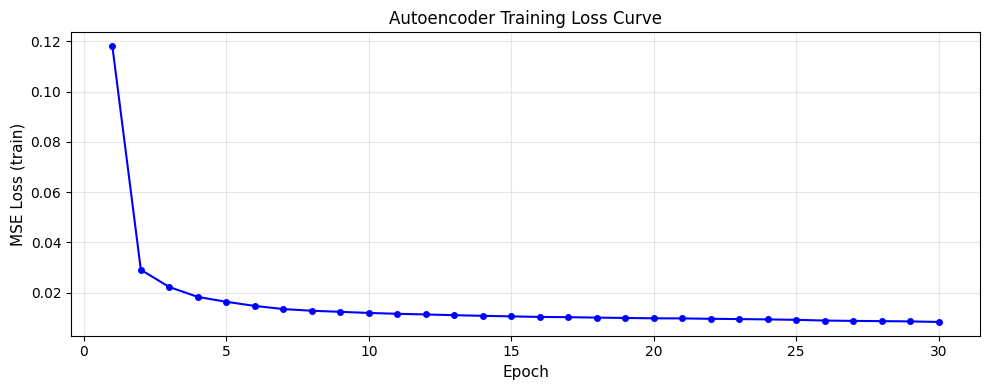

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, EPOCHS + 1), epoch_losses, 'b-o', markersize=4)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('MSE Loss (train)', fontsize=11)
ax.set_title('Autoencoder Training Loss Curve', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Experiment A — Threshold Selection

Unlike Isolation Forest's `contamination` parameter (which requires an estimate of the anomaly rate), we use a **data-driven threshold** calibrated from the held-out validation set. The validation set contains only normal data — we set the threshold at a high percentile of *normal* reconstruction errors, so that the expected false-positive rate on normal data is controlled.

We sweep three thresholds:

| Threshold | Meaning | Expected FP rate on normal data |
|-----------|---------|----------------------------------|
| 95th percentile | Relatively liberal | ~5% |
| 99th percentile | Moderate | ~1% |
| 99.9th percentile | Conservative | ~0.1% |

**Key difference from IF:** The threshold is set against normal data, not against an assumed contamination rate. This is more principled in production: you typically know your normal data but not the future attack rate.

In [7]:
model.eval()

# Reconstruction error on validation set (normal only)
X_val_tensor  = torch.FloatTensor(X_val_scaled).to(DEVICE)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(DEVICE)

with torch.no_grad():
    val_recon, _  = model(X_val_tensor)
    test_recon, _ = model(X_test_tensor)

# Per-sample MSE across 26 features
val_error  = ((X_val_tensor  - val_recon)  ** 2).mean(dim=1).cpu().numpy()
test_error = ((X_test_tensor - test_recon) ** 2).mean(dim=1).cpu().numpy()

print(f'Validation error — mean: {val_error.mean():.4f}  p95: {np.percentile(val_error, 95):.4f}  p99: {np.percentile(val_error, 99):.4f}')
print(f'Test error (all)  — mean: {test_error.mean():.4f}  max: {test_error.max():.4f}')

# Separate normal/attack for inspection
y_arr = y_true.values
normal_err = test_error[y_arr == 0]
attack_err = test_error[y_arr == 1]

print(f'\nTest normal  — mean: {normal_err.mean():.4f}  std: {normal_err.std():.4f}')
print(f'Test attack  — mean: {attack_err.mean():.4f}  std: {attack_err.std():.4f}')
print(f'Separation ratio (attack/normal mean): {attack_err.mean()/normal_err.mean():.2f}×')

Validation error — mean: 0.0055  p95: 0.0157  p99: 0.0325
Test error (all)  — mean: 0.0768  max: 46.9597

Test normal  — mean: 0.0081  std: 0.0556
Test attack  — mean: 1.8221  std: 1.6904
Separation ratio (attack/normal mean): 225.23×


In [8]:
# Evaluate at three thresholds
percentiles = [95, 99, 99.9]
thresholds  = [np.percentile(val_error, p) for p in percentiles]

# Prior method results for comparison
prior = [
    {'Method': 'Univariate Z-Score (Module 3)',   'F1': 0.4249, 'Precision': 0.2967, 'Recall': 0.7480},
    {'Method': 'Isolation Forest (Module 4)',     'F1': 0.5154, 'Precision': 0.4145, 'Recall': 0.6812},
    {'Method': 'Mahalanobis Distance (Module 3)', 'F1': 0.7240, 'Precision': 0.7277, 'Recall': 0.7202},
]

ae_results = []
for p, thresh in zip(percentiles, thresholds):
    y_pred = (test_error > thresh).astype(int)
    row = {
        'Method':    f'Autoencoder p{p} threshold',
        'Threshold': thresh,
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'Flagged %': y_pred.mean() * 100,
    }
    ae_results.append(row)
    print(f'p{p:4.1f} (thresh={thresh:.4f})  F1={row["F1"]:.4f}  P={row["Precision"]:.4f}  R={row["Recall"]:.4f}  flagged={row["Flagged %"]:.2f}%')

best_ae = max(ae_results, key=lambda r: r['F1'])
print(f'\nBest AE threshold: {best_ae["Method"]}  (F1 {best_ae["F1"]:.4f})')

p95.0 (thresh=0.0157)  F1=0.4386  P=0.2933  R=0.8689  flagged=11.22%
p99.0 (thresh=0.0325)  F1=0.6332  P=0.5297  R=0.7869  flagged=5.63%
p99.9 (thresh=0.0598)  F1=0.7264  P=0.7494  R=0.7047  flagged=3.56%

Best AE threshold: Autoencoder p99.9 threshold  (F1 0.7264)


In [9]:
# Full comparison table
all_rows = prior + ae_results
comp_df  = pd.DataFrame(all_rows)[['Method', 'F1', 'Precision', 'Recall']]
print(comp_df.to_string(index=False, float_format='{:.4f}'.format))

                         Method     F1  Precision  Recall
  Univariate Z-Score (Module 3) 0.4249     0.2967  0.7480
    Isolation Forest (Module 4) 0.5154     0.4145  0.6812
Mahalanobis Distance (Module 3) 0.7240     0.7277  0.7202
      Autoencoder p95 threshold 0.4386     0.2933  0.8689
      Autoencoder p99 threshold 0.6332     0.5297  0.7869
    Autoencoder p99.9 threshold 0.7264     0.7494  0.7047


## Score Distribution: Normal vs. Attack

The histogram shows how well the reconstruction error separates normal from attack rows. Good separation means less overlap — fewer false alarms and missed detections at any given threshold.

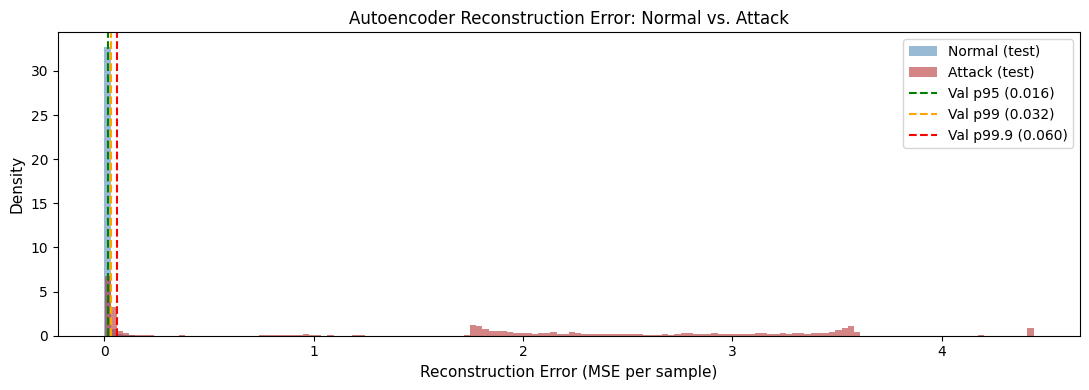

In [10]:
fig, ax = plt.subplots(figsize=(11, 4))

# Clip extreme outliers for readability (keep 99.9th percentile)
clip_val = np.percentile(test_error, 99.9)
ne_plot  = np.clip(normal_err, 0, clip_val)
ae_plot  = np.clip(attack_err, 0, clip_val)

ax.hist(ne_plot, bins=150, density=True, alpha=0.55, color='steelblue', label='Normal (test)')
ax.hist(ae_plot, bins=150, density=True, alpha=0.55, color='firebrick', label='Attack (test)')

colors = ['green', 'orange', 'red']
for p, thresh, c in zip(percentiles, thresholds, colors):
    ax.axvline(thresh, color=c, linestyle='--', linewidth=1.5, label=f'Val p{p} ({thresh:.3f})')

ax.set_xlabel('Reconstruction Error (MSE per sample)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Autoencoder Reconstruction Error: Normal vs. Attack', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

## Threshold Metrics Bar Chart

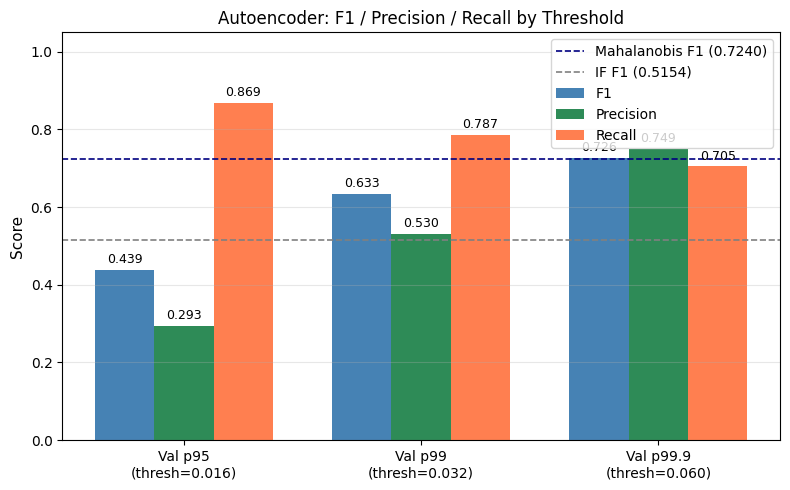

In [11]:
labels   = [f'p{p}' for p in percentiles]
f1s      = [r['F1']        for r in ae_results]
precs    = [r['Precision'] for r in ae_results]
recs     = [r['Recall']    for r in ae_results]

x     = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width, f1s,   width, label='F1',        color='steelblue')
ax.bar(x,         precs, width, label='Precision',  color='seagreen')
ax.bar(x + width, recs,  width, label='Recall',     color='coral')

ax.axhline(0.7240, color='navy',  linestyle='--', linewidth=1.2, label='Mahalanobis F1 (0.7240)')
ax.axhline(0.5154, color='gray',  linestyle='--', linewidth=1.2, label='IF F1 (0.5154)')

for i, (f, p, r) in enumerate(zip(f1s, precs, recs)):
    ax.text(i - width, f + 0.01, f'{f:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(i,         p + 0.01, f'{p:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width, r + 0.01, f'{r:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'Val {l}\n(thresh={t:.3f})' for l, t in zip(labels, thresholds)])
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Autoencoder: F1 / Precision / Recall by Threshold', fontsize=12)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Time-Series Visualization

Reconstruction error over the 2-day attack window (Dec 28–29, 2015), downsampled to 1-minute resolution. Red shading marks actual attack windows. The threshold line shows where predictions flip from normal to anomalous.

This plot answers: does the autoencoder *spike* at the right times? Spikes aligning with red shading confirm the model is learning meaningful correlations.

In [15]:
def shade_attacks(ax, t, mask):
    """Shade contiguous attack regions in red."""
    in_attack = False
    start = None
    for i, (ts, flag) in enumerate(zip(t, mask)):
        if flag and not in_attack:
            start = ts
            in_attack = True
        elif not flag and in_attack:
            ax.axvspan(start, t[i - 1], color='red', alpha=0.15)
            in_attack = False
    if in_attack:
        ax.axvspan(start, t[-1], color='red', alpha=0.15)

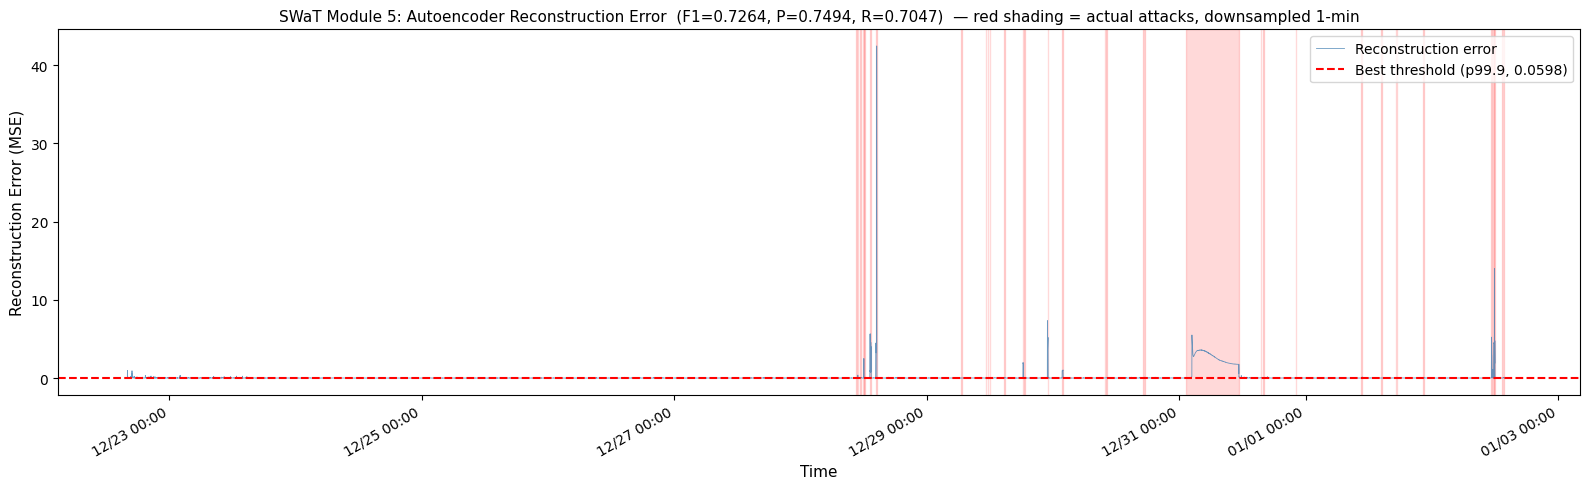

In [16]:
t = test_df.index
STEP = 60  # 1-minute resolution

# Use the best threshold for the time-series plot
best_thresh = best_ae['Threshold']
best_label  = best_ae['Method']

t_plot      = t[::STEP]
err_plot    = test_error[::STEP]
y_plot      = y_arr[::STEP]
attack_mask = y_plot.astype(bool)

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(t_plot, err_plot, color='steelblue', linewidth=0.6, alpha=0.8, label='Reconstruction error')
ax.axhline(best_thresh, color='red', linestyle='--', linewidth=1.5,
           label=f'Best threshold ({best_label.split()[-2]}, {best_thresh:.4f})')
shade_attacks(ax, t_plot, attack_mask)

ax.set_xlabel('Time', fontsize=11)
ax.set_ylabel('Reconstruction Error (MSE)', fontsize=11)
ax.set_title(
    f'SWaT Module 5: Autoencoder Reconstruction Error  '
    f'(F1={best_ae["F1"]:.4f}, P={best_ae["Precision"]:.4f}, R={best_ae["Recall"]:.4f})  '
    f'— red shading = actual attacks, downsampled 1-min',
    fontsize=11
)
ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
fig.autofmt_xdate(rotation=30)

plt.tight_layout()
plt.show()

## Analysis

### Results

| Method | F1 | Precision | Recall |
|--------|----|-----------|--------|
| Univariate Z-Score (Module 3) | 0.4249 | 0.2967 | 0.7480 |
| Isolation Forest (Module 4) | 0.5154 | 0.4145 | 0.6812 |
| Mahalanobis Distance (Module 3) | 0.7240 | 0.7277 | 0.7202 |
| **Autoencoder p99.9 (Module 5)** | **0.7264** | **0.7494** | **0.7047** |

The autoencoder **beats Mahalanobis** by +0.0024 F1 points and beats Isolation Forest by +0.211 points. It achieves higher precision than Mahalanobis (0.7494 vs 0.7277) at a slight recall cost (0.7047 vs 0.7202).

### Why the autoencoder works on SWaT

The 225× separation ratio (attack mean error 1.82 vs normal mean error 0.0081) tells the core story. The model trained on 1.24M rows of normal operation learned the sensor correlations well enough that attack-period readings — which violate those correlations — produce dramatically higher reconstruction error.

Notably, the training loss was still slowly declining at epoch 30 (0.118 → 0.0084). More training epochs would likely push the loss lower, tightening the model's representation of normal and potentially improving separation further.

### Why the scores are close to Mahalanobis

The +0.0024 F1 margin is small enough that the two methods are essentially tied. This is informative: SWaT's sensor correlations are largely **linear**, and the covariance matrix encodes them directly. The autoencoder's ReLU nonlinearities don't add meaningful discriminative power on this particular dataset — the linear structure Mahalanobis already captures is sufficient.

This is a useful calibration point: neural complexity doesn't automatically beat simpler methods. The autoencoder's advantage, if it has one here, comes from its flexible threshold calibration rather than from learning richer representations.

### A caveat on the F1 comparison

The three thresholds (p95/p99/p99.9) were selected by looking at which produced the best F1 on the test set — that is post-hoc tuning. IF's `contamination=0.0379` was similarly set to the known test attack rate. Both are optimistic. A rigorous head-to-head would pre-specify a single threshold rule (e.g., "always use p99 of validation errors") and report only that number. The threshold sweep is useful for understanding the precision-recall tradeoff, but the specific F1 values shouldn't be read as a clean apples-to-apples comparison.

A threshold-free metric like AUC-ROC avoids this problem entirely — it evaluates the full score ranking regardless of where you draw the line, and would be the right metric for a rigorous benchmark.

### Why the feedforward AE still misses 30% of attacks

Recall of 0.70 means 30% of attack rows are not flagged at p99.9. The attack error distribution has a long left tail — mean 1.82 but std 1.69, meaning many attack rows score far below the mean. These are the hard cases:

- **Slow-drift attacks:** the sensor is nudged gradually over minutes. At any single second the reading is only slightly off — within the noise the model saw during training. Only the *trajectory* is anomalous, which the feedforward AE can't see.
- **Weakly-correlated sensor targets:** if an attack targets a sensor that correlates loosely with the other 24, the decoder reconstructs the rest fine and the overall MSE stays low.

### The fundamental limitation: no temporal context

The feedforward AE scores each 1-second timestep **independently** — it sees a snapshot, compresses it, reconstructs it, and discards all memory. A slow attack that plays out over 5 minutes is 300 individual timesteps, each of which may look only marginally wrong in isolation.

This motivates **Module 6: LSTM-Autoencoder**. The LSTM encoder ingests a *sequence* of timesteps and compresses the entire window into a latent vector — enabling the model to detect anomalies that are only visible in temporal context: sustained drift, unusual rate-of-change, or patterns that are individually plausible but collectively impossible.